# Central Limit Theorem & Confidence Intervals — Hands-On

This notebook accompanies the [README](README.md) and demonstrates three ideas using simulation:

1. **Sample distributions** drawn from a population — how a single sample compares to the whole.
2. **The sampling distribution of the mean** — what happens when we take *many* samples and look at the distribution of their means.
3. **Confidence intervals** — how to construct and interpret them.

The Central Limit Theorem (CLT) states that, regardless of the shape of the underlying population, the distribution of sample means becomes approximately **normal** once the sample size is large enough (a common rule of thumb is *n ≥ 30*). We will *see* this happen.


## 1. Setup

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RNG = np.random.default_rng(seed=42)

sns.set_theme(style="whitegrid")

## 2. Build a population

We will use a deliberately **non-normal** population (uniform on `[0, 1000]`) so that the CLT's "regardless of population shape" claim is visible. The mean of a `Uniform(0, 1000)` distribution is 500 and its standard deviation is `1000/√12 ≈ 288.68`.

In [10]:
POPULATION_SIZE = 10_000
population = RNG.integers(0, 1001, size=POPULATION_SIZE)

pop_mean = population.mean()
pop_std = population.std()
print(f"Population mean (μ): {pop_mean:.2f}")
print(f"Population std  (σ): {pop_std:.2f}")

Population mean (μ): 496.37
Population std  (σ): 287.60


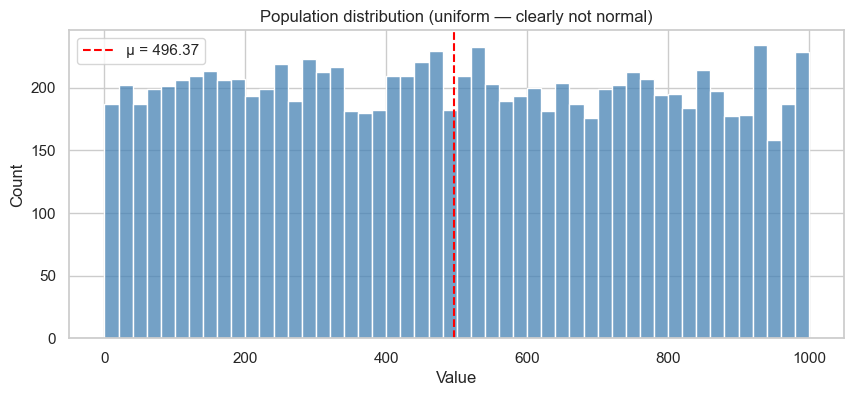

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(population, bins=50, ax=ax, color="steelblue")
ax.axvline(pop_mean, color="red", linestyle="--", label=f"μ = {pop_mean:.2f}")
ax.set_title("Population distribution (uniform — clearly not normal)")
ax.set_xlabel("Value")
ax.legend()
plt.show()

## 3. Single samples of varying sizes

Each individual sample is itself a small distribution. With very few observations, a sample's mean can land far from the population mean. As the sample size grows, single samples already start to look more representative of the population.

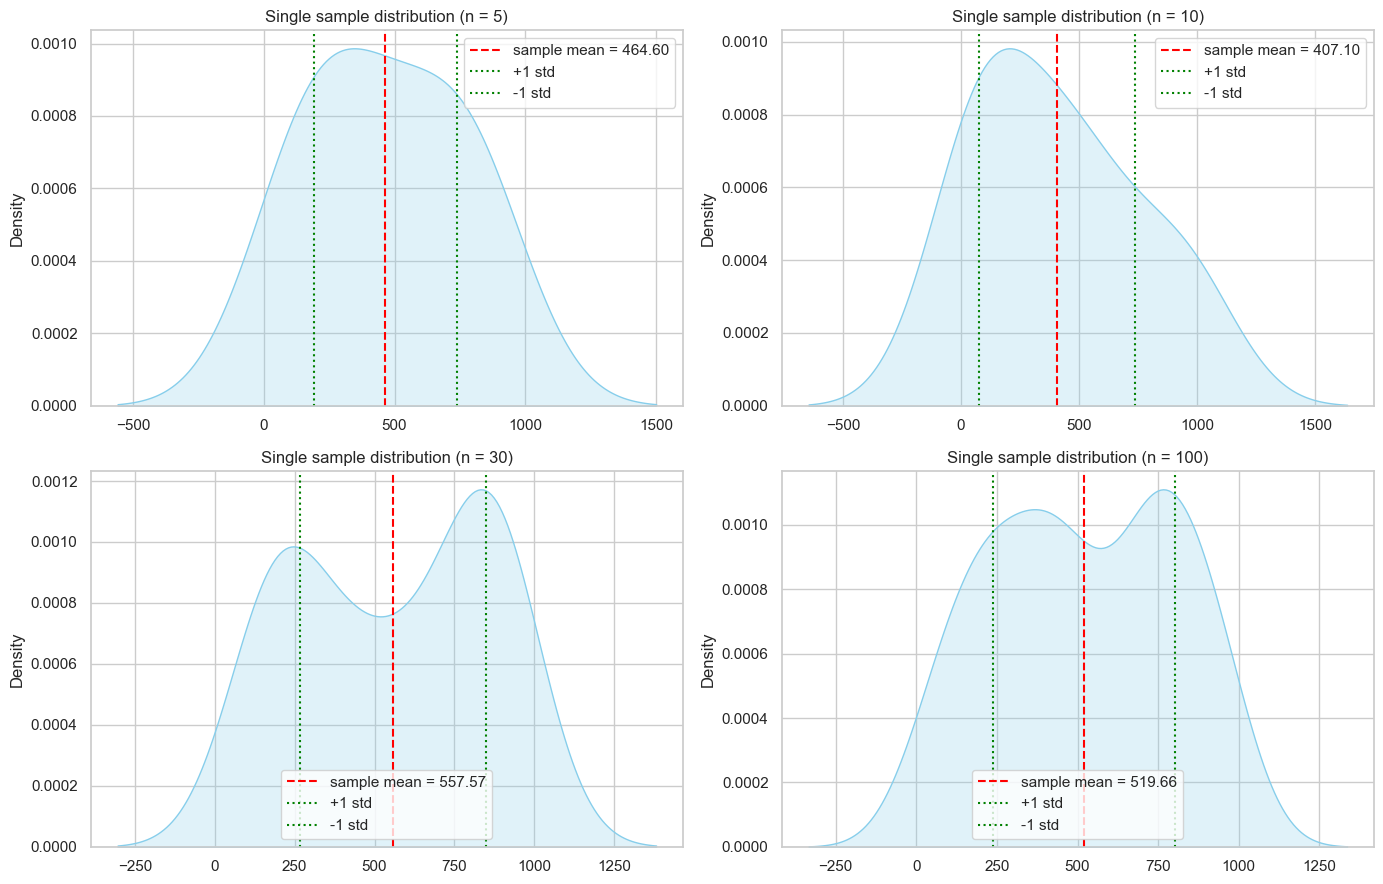

In [12]:
def plot_sample(ax, samples, title):
    mean = np.mean(samples)
    std = np.std(samples)
    sns.kdeplot(samples, ax=ax, fill=True, color="skyblue")
    ax.axvline(mean, color="red", linestyle="--", label=f"sample mean = {mean:.2f}")
    ax.axvline(mean + std, color="green", linestyle=":", label="+1 std")
    ax.axvline(mean - std, color="green", linestyle=":", label="-1 std")
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, n in zip(axes.flat, [5, 10, 30, 100]):
    sample = RNG.choice(population, size=n, replace=False)
    plot_sample(ax, sample, f"Single sample distribution (n = {n})")
plt.tight_layout()
plt.show()

## 4. The sampling distribution of the mean

Now the key experiment. Instead of looking at one sample, we draw **many** samples of a fixed size `n`, compute the mean of each, and plot the distribution of those means.

The CLT predicts that:

- The mean of the sampling distribution should equal μ.
- Its standard deviation (the **standard error**) should equal σ / √n.
- Its shape should approach a **normal distribution** as `n` grows — even though our population is uniform.


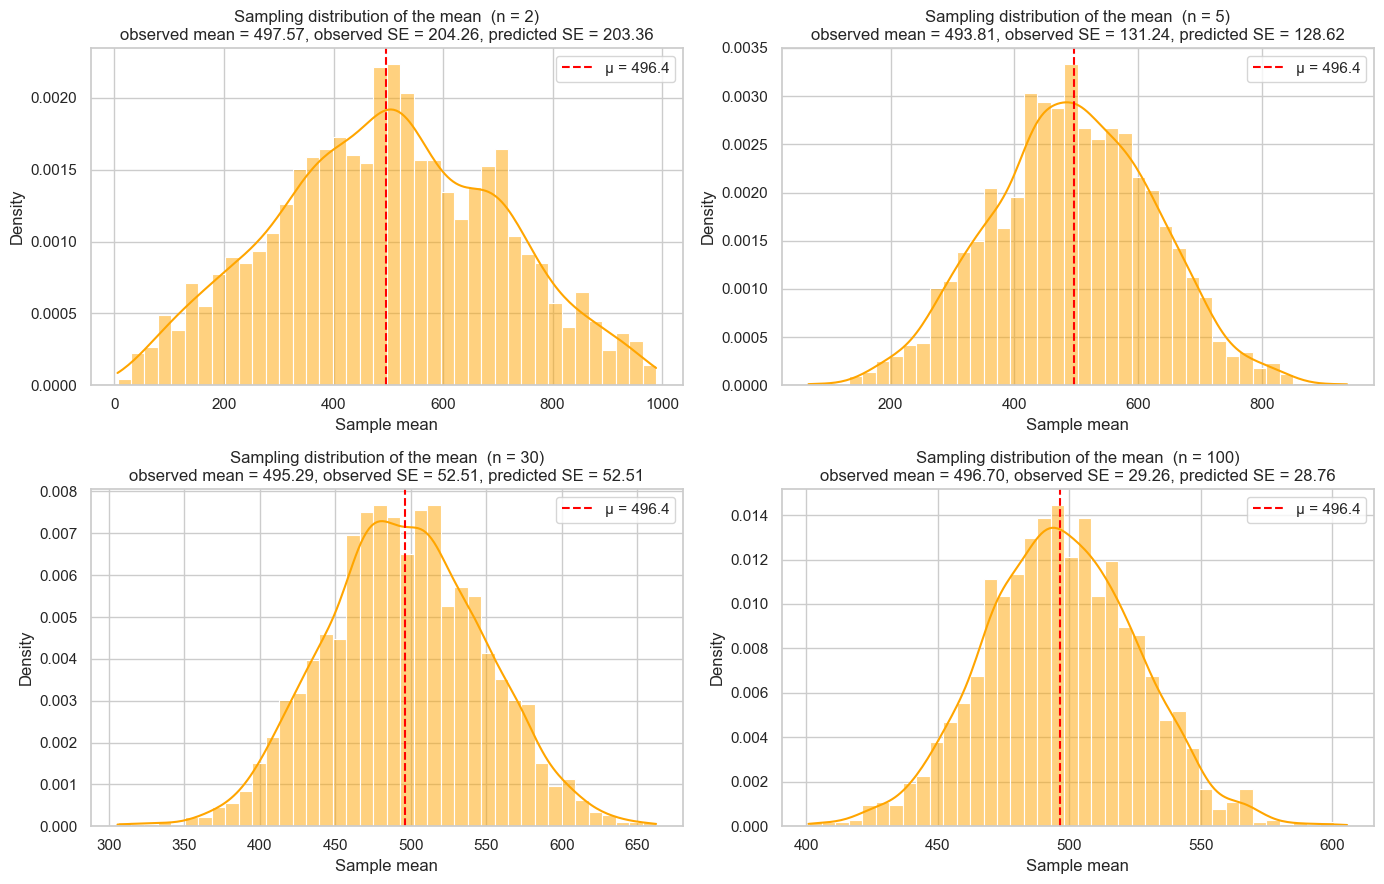

In [13]:
def sampling_distribution_of_mean(population, sample_size, n_samples=2000, rng=RNG):
    means = np.empty(n_samples)
    for i in range(n_samples):
        means[i] = rng.choice(population, size=sample_size, replace=True).mean()
    return means


sample_sizes = [2, 5, 30, 100]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, n in zip(axes.flat, sample_sizes):
    means = sampling_distribution_of_mean(population, sample_size=n)
    expected_se = pop_std / np.sqrt(n)

    sns.histplot(means, bins=40, kde=True, ax=ax, color="orange", stat="density")
    ax.axvline(pop_mean, color="red", linestyle="--", label=f"μ = {pop_mean:.1f}")
    ax.set_title(
        f"Sampling distribution of the mean  (n = {n})\n"
        f"observed mean = {means.mean():.2f}, observed SE = {means.std():.2f}, "
        f"predicted SE = {expected_se:.2f}"
    )
    ax.set_xlabel("Sample mean")
    ax.legend()

plt.tight_layout()
plt.show()

**What to notice:**

- The center of every sampling distribution sits on the population mean μ ≈ 500.
- The observed standard error tracks the prediction `σ / √n` closely.
- As `n` grows from 2 → 100, the shape becomes visibly more bell-curved — even though we sampled from a uniform population.

This is the CLT in action.

## 5. Confidence intervals

A 95% confidence interval is the range

> **x̄ ± z · (σ / √n)**

where `z = 1.96` for 95% confidence (and `z = 1.645` for 90%, `z = 2.576` for 99%).

Let us construct a CI from a single sample, then check how often a 95% CI actually contains μ when we repeat the experiment many times — the *frequentist* interpretation of "95% confidence".

In [14]:
def confidence_interval(sample, confidence=0.95, sigma=None):
    n = len(sample)
    x_bar = sample.mean()
    sigma = sample.std(ddof=1) if sigma is None else sigma
    z = {0.90: 1.645, 0.95: 1.960, 0.99: 2.576}[confidence]
    margin = z * sigma / np.sqrt(n)
    return x_bar - margin, x_bar + margin


# One sample, n = 100
one_sample = RNG.choice(population, size=100, replace=True)
ci_low, ci_high = confidence_interval(one_sample, confidence=0.95, sigma=pop_std)
print(f"Sample mean: {one_sample.mean():.2f}")
print(f"95% CI:      ({ci_low:.2f}, {ci_high:.2f})")
print(f"True μ:      {pop_mean:.2f}  -> {'inside' if ci_low <= pop_mean <= ci_high else 'OUTSIDE'} the CI")

Sample mean: 527.28
95% CI:      (470.91, 583.65)
True μ:      496.37  -> inside the CI


### How often does a 95% CI actually cover μ?

If we construct a 95% CI from many different samples, *roughly 95% of those intervals* should contain the true population mean. Let us verify.

In [15]:
N_TRIALS = 1000
SAMPLE_SIZE = 100

contained = 0
intervals = []

for _ in range(N_TRIALS):
    sample = RNG.choice(population, size=SAMPLE_SIZE, replace=True)
    lo, hi = confidence_interval(sample, confidence=0.95, sigma=pop_std)
    intervals.append((lo, hi))
    if lo <= pop_mean <= hi:
        contained += 1

print(f"Out of {N_TRIALS} 95% confidence intervals, {contained} contained the true mean.")
print(f"Empirical coverage: {contained / N_TRIALS:.1%}")

Out of 1000 95% confidence intervals, 959 contained the true mean.
Empirical coverage: 95.9%


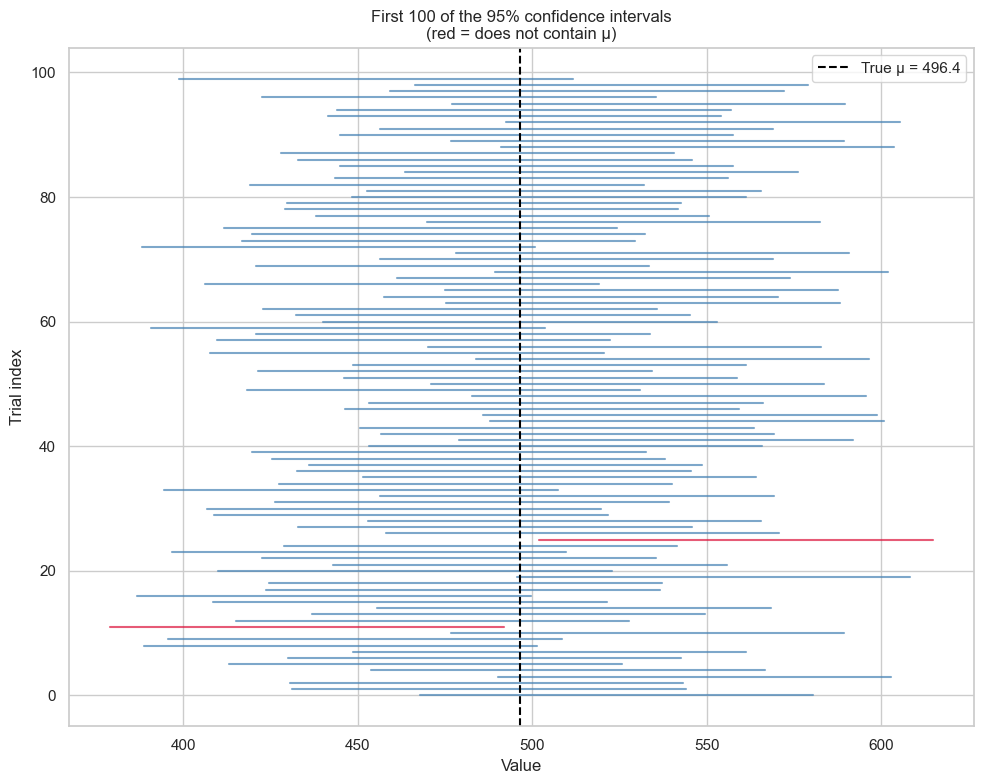

In [16]:
# Visualize the first 100 intervals
fig, ax = plt.subplots(figsize=(10, 8))
for i, (lo, hi) in enumerate(intervals[:100]):
    color = "steelblue" if lo <= pop_mean <= hi else "crimson"
    ax.plot([lo, hi], [i, i], color=color, alpha=0.7)
ax.axvline(pop_mean, color="black", linestyle="--", label=f"True μ = {pop_mean:.1f}")
ax.set_xlabel("Value")
ax.set_ylabel("Trial index")
ax.set_title("First 100 of the 95% confidence intervals\n(red = does not contain μ)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Takeaways

- **Sampling distribution of the mean** ≠ the distribution of a single sample. It is the distribution of *means computed from many samples*.
- The **Central Limit Theorem** lets us treat that sampling distribution as approximately normal once `n ≳ 30`, regardless of the population's shape.
- **Standard error** decreases like `1/√n` — quadrupling the sample size halves the standard error.
- A **95% confidence interval** does not say *"there is a 95% chance μ is in this interval"*. It says *"if we repeat this procedure many times, ~95% of the constructed intervals will contain μ"*. The simulation above demonstrates that frequentist interpretation directly.